In [1]:
# all imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss, average_precision_score
import time
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve
from catboost import Pool
import json
from pathlib import Path

In [2]:
# for saving images
Path("results").mkdir(exist_ok=True)

def save_fig(fig, name, dpi=150):
    fig.savefig(f"results/{name}.png", dpi=dpi, bbox_inches="tight")
    fig.savefig(f"results/{name}.pdf", bbox_inches="tight")
    print(f"saved {name}")

## Data Cleaning

In [3]:
train = pd.read_csv('widsdatathon2020/training_v2.csv')
train

,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,66154,25312,118,0,68.0,22.730000,0,Caucasian,M,180.3,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
1,114252,59342,81,0,77.0,27.420000,0,Caucasian,F,160.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory
2,119783,50777,118,0,25.0,31.950000,0,Caucasian,F,172.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic
3,79267,46918,118,0,81.0,22.640000,1,Caucasian,F,165.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular
4,92056,34377,33,0,19.0,NaN,0,Caucasian,M,188.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Trauma,Trauma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91708,91592,78108,30,0,75.0,23.060250,0,Caucasian,M,177.8,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,Sepsis,Cardiovascular
91709,66119,13486,121,0,56.0,47.179671,0,Caucasian,F,183.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
91710,8981,58179,195,0,48.0,27.236914,0,Caucasian,M,170.2,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic
91711,33776,120598,66,0,NaN,23.297481,0,Caucasian,F,154.9,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory


__All columns for easy reference__

encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,hospital_admit_source,
icu_admit_source,icu_id,icu_stay_type,icu_type,pre_icu_los_days,readmission_status,weight,albumin_apache,apache_2_diagnosis,
apache_3j_diagnosis,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,
gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,
paco2_apache,paco2_for_ph_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,
wbc_apache,d1_diasbp_invasive_max,d1_diasbp_invasive_min,d1_diasbp_max,d1_diasbp_min,d1_diasbp_noninvasive_max,d1_diasbp_noninvasive_min,
d1_heartrate_max,d1_heartrate_min,d1_mbp_invasive_max,d1_mbp_invasive_min,d1_mbp_max,d1_mbp_min,d1_mbp_noninvasive_max,
d1_mbp_noninvasive_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_invasive_max,d1_sysbp_invasive_min,d1_sysbp_max,
d1_sysbp_min,d1_sysbp_noninvasive_max,d1_sysbp_noninvasive_min,d1_temp_max,d1_temp_min,h1_diasbp_invasive_max,h1_diasbp_invasive_min,
h1_diasbp_max,h1_diasbp_min,h1_diasbp_noninvasive_max,h1_diasbp_noninvasive_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_invasive_max,
h1_mbp_invasive_min,h1_mbp_max,h1_mbp_min,h1_mbp_noninvasive_max,h1_mbp_noninvasive_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,
h1_spo2_min,h1_sysbp_invasive_max,h1_sysbp_invasive_min,h1_sysbp_max,h1_sysbp_min,h1_sysbp_noninvasive_max,h1_sysbp_noninvasive_min,
h1_temp_max,h1_temp_min,d1_albumin_max,d1_albumin_min,d1_bilirubin_max,d1_bilirubin_min,d1_bun_max,d1_bun_min,d1_calcium_max,
d1_calcium_min,d1_creatinine_max,d1_creatinine_min,d1_glucose_max,d1_glucose_min,d1_hco3_max,d1_hco3_min,d1_hemaglobin_max,
d1_hemaglobin_min,d1_hematocrit_max,d1_hematocrit_min,d1_inr_max,d1_inr_min,d1_lactate_max,d1_lactate_min,d1_platelets_max,
d1_platelets_min,d1_potassium_max,d1_potassium_min,d1_sodium_max,d1_sodium_min,d1_wbc_max,d1_wbc_min,h1_albumin_max,h1_albumin_min,
h1_bilirubin_max,h1_bilirubin_min,h1_bun_max,h1_bun_min,h1_calcium_max,h1_calcium_min,h1_creatinine_max,h1_creatinine_min,h1_glucose_max,
h1_glucose_min,h1_hco3_max,h1_hco3_min,h1_hemaglobin_max,h1_hemaglobin_min,h1_hematocrit_max,h1_hematocrit_min,h1_inr_max,h1_inr_min,
h1_lactate_max,h1_lactate_min,h1_platelets_max,h1_platelets_min,h1_potassium_max,h1_potassium_min,h1_sodium_max,h1_sodium_min,h1_wbc_max,
h1_wbc_min,d1_arterial_pco2_max,d1_arterial_pco2_min,d1_arterial_ph_max,d1_arterial_ph_min,d1_arterial_po2_max,d1_arterial_po2_min,
d1_pao2fio2ratio_max,d1_pao2fio2ratio_min,h1_arterial_pco2_max,h1_arterial_pco2_min,h1_arterial_ph_max,h1_arterial_ph_min,
h1_arterial_po2_max,h1_arterial_po2_min,h1_pao2fio2ratio_max,h1_pao2fio2ratio_min,apache_4a_hospital_death_prob,apache_4a_icu_death_prob,
aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,
apache_2_bodysystem

In [4]:
train['readmission_status'].nunique()

1

First, let us sort the columns into groups

In [5]:
TARGET = "hospital_death"
RANDOM_STATE = 42

# --- column roles (cleaner AND build_feature_frame both read these) -------
ID_COLS   = ["encounter_id", "patient_id"]
GROUP_IDS = ["hospital_id", "icu_id"]
CODE_CAT_COLS = ["apache_2_diagnosis", "apache_3j_diagnosis"]
CONSTANT_DROP = ["readmission_status"] # only one value
APACHE_PROB_COLS = ["apache_4a_hospital_death_prob", "apache_4a_icu_death_prob"]

BINARY_COLS = [
    "elective_surgery", "apache_post_operative", "arf_apache", "gcs_unable_apache",
    "intubated_apache", "ventilated_apache", "aids", "cirrhosis", "diabetes_mellitus",
    "hepatic_failure", "immunosuppression", "leukemia", "lymphoma", "solid_tumor_with_metastasis",
]
LOWCARD_CAT_COLS = [
    "ethnicity", "gender", "hospital_admit_source", "icu_admit_source",
    "icu_stay_type", "icu_type", "apache_3j_bodysystem", "apache_2_bodysystem",
]

# --- APACHE scores ---
APACHE_COVARIATE_COLS = [
    "albumin_apache","bilirubin_apache","bun_apache","creatinine_apache","fio2_apache",
    "glucose_apache","heart_rate_apache","hematocrit_apache","map_apache","paco2_apache",
    "paco2_for_ph_apache","pao2_apache","ph_apache","resprate_apache","sodium_apache",
    "temp_apache","urineoutput_apache","wbc_apache","gcs_eyes_apache","gcs_motor_apache",
    "gcs_verbal_apache","gcs_unable_apache","arf_apache","intubated_apache",
    "ventilated_apache","apache_post_operative",
]
APACHE_CODE_COLS = ["apache_2_diagnosis","apache_3j_diagnosis","apache_2_bodysystem","apache_3j_bodysystem"]

# --- physiological bounds: values outside [lo, hi] -> NaN ---
BOUNDS = {  # applied to every d1/h1/max/min/invasive variant
    "heartrate": (1, 300), "sysbp": (1, 300), "diasbp": (1, 250), "mbp": (1, 250),
    "resprate": (1, 100), "spo2": (1, 100), "temp": (25, 45),
    "albumin": (0.5, 6), "bilirubin": (0, 60), "bun": (0, 250), "calcium": (2, 20),
    "creatinine": (0, 30), "glucose": (10, 1500), "hco3": (5, 60), "hemaglobin": (1, 25),
    "hematocrit": (5, 75), "inr": (0.3, 20), "lactate": (0, 40), "platelets": (1, 1500),
    "potassium": (1, 12), "sodium": (100, 200), "wbc": (0, 250),
    "arterial_pco2": (5, 150), "arterial_ph": (6.5, 8.0), "arterial_po2": (10, 800),
    "pao2fio2ratio": (10, 1000),
}
APACHE_TO_BASE = {
    "heart_rate_apache": "heartrate", "map_apache": "mbp", "resprate_apache": "resprate",
    "temp_apache": "temp", "albumin_apache": "albumin", "bilirubin_apache": "bilirubin",
    "bun_apache": "bun", "creatinine_apache": "creatinine", "glucose_apache": "glucose",
    "hematocrit_apache": "hematocrit", "sodium_apache": "sodium", "wbc_apache": "wbc",
    "paco2_apache": "arterial_pco2", "paco2_for_ph_apache": "arterial_pco2",
    "pao2_apache": "arterial_po2", "ph_apache": "arterial_ph",
}
EXTRA_BOUNDS = {
    "age": (0, 120), "height": (100, 250), "weight": (20, 400), "bmi": (10, 100),
    "pre_icu_los_days": (0, 365), "fio2_apache": (0.21, 1.0), "urineoutput_apache": (0, 12000),
    "gcs_eyes_apache": (1, 4), "gcs_motor_apache": (1, 6), "gcs_verbal_apache": (1, 5),
    # APACHE probabilities: negatives -> NaN, valid probability range [0,1]
    "apache_4a_hospital_death_prob": (0, 1), "apache_4a_icu_death_prob": (0, 1),
}

In [6]:
def to_object_nan(s):
    out = s.astype("string").str.strip().replace(
        {"": pd.NA, "nan": pd.NA, "NaN": pd.NA, "None": pd.NA, "<NA>": pd.NA})
    return out.astype(object).where(out.notna(), np.nan)

def _timeseries_base():
    WIN, AGG = ["d1", "h1"], ["max", "min"]
    PLAIN = ["heartrate", "resprate", "spo2", "temp"]
    BP = ["sysbp", "diasbp", "mbp"]
    LABS = ["albumin","bilirubin","bun","calcium","creatinine","glucose","hco3","hemaglobin",
            "hematocrit","inr","lactate","platelets","potassium","sodium","wbc"]
    GAS = ["arterial_pco2","arterial_ph","arterial_po2","pao2fio2ratio"]
    m = {}
    for w in WIN:
        for a in AGG:
            for v in PLAIN: m[f"{w}_{v}_{a}"] = v
            for bp in BP:
                m[f"{w}_{bp}_{a}"] = bp
                m[f"{w}_{bp}_invasive_{a}"] = bp
                m[f"{w}_{bp}_noninvasive_{a}"] = bp
            for lab in LABS: m[f"{w}_{lab}_{a}"] = lab
            for g in GAS:    m[f"{w}_{g}_{a}"] = g
    return m

def _bounds_map():
    cb = {}
    for col, base in {**_timeseries_base(), **APACHE_TO_BASE}.items():
        if base in BOUNDS: cb[col] = BOUNDS[base]
    cb.update(EXTRA_BOUNDS)
    return cb

def clean_deterministic(df, add_indicators=False, indicator_threshold=0.30,
                        null_maxmin_violations=True, verbose=True):
    df = df.copy()
    report = {}
    present = lambda cols: [c for c in cols if c in df.columns]

    # drop non-features
    for c in present(CONSTANT_DROP):
        report.setdefault("dropped", {})[c] = f"nunique={df[c].nunique(dropna=False)}"
        df = df.drop(columns=[c])
    zero_var = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
    dup_cols = df.columns[df.T.duplicated()].tolist()
    if zero_var: report["zero_variance_dropped"] = zero_var; df = df.drop(columns=zero_var)
    if dup_cols: report["duplicate_columns_dropped"] = dup_cols; df = df.drop(columns=dup_cols)

    # row-level structure
    report["duplicate_rows"] = int(df.duplicated().sum())
    if "patient_id" in df.columns:
        report["patients_with_multiple_encounters"] = int((df["patient_id"].value_counts() > 1).sum())

    # dtype coercion
    for c in present(BINARY_COLS):
        df[c] = pd.to_numeric(df[c], errors="coerce")
        df.loc[~df[c].isin([0, 1]), c] = np.nan # float with np.nan
    for c in present(GROUP_IDS + CODE_CAT_COLS + LOWCARD_CAT_COLS):
        df[c] = to_object_nan(df[c]) # object + np.nan

    # physiological bounds -> NaN 
    nulled = {}
    for c, (lo, hi) in _bounds_map().items():
        if c in df.columns:
            s = pd.to_numeric(df[c], errors="coerce")
            bad = (s < lo) | (s > hi)
            if bad.sum(): nulled[c] = int(bad.sum())
            s[bad] = np.nan
            df[c] = s
    report["values_nulled_out_of_range"] = nulled

    # consistency checks with max/min structure
    cols = set(df.columns)
    mm = 0
    for mx in [c for c in cols if c.endswith("_max") and c[:-4] + "_min" in cols]:
        mn = mx[:-4] + "_min"
        bad = df[mx] < df[mn]
        mm += int(bad.sum())
        if null_maxmin_violations: df.loc[bad, [mx, mn]] = np.nan
    report["maxmin_violations"] = mm
    d1h1 = 0
    for d in [c for c in cols if c.startswith("d1_") and "h1_" + c[3:] in cols]:
        h = "h1_" + d[3:]
        if d.endswith("_max"):   d1h1 += int((df[d] < df[h]).sum())
        elif d.endswith("_min"): d1h1 += int((df[d] > df[h]).sum())
    report["d1_contains_h1_violations"] = d1h1

    # informative-missingness flags
    if add_indicators:
        miss = df.isna().mean()
        skip = set(ID_COLS + GROUP_IDS + [TARGET] + LOWCARD_CAT_COLS + CODE_CAT_COLS)
        ind = [c for c in miss[miss > indicator_threshold].index if c not in skip]
        for c in ind: df[f"{c}__was_missing"] = df[c].isna().astype("int8")
        report["missing_indicators_added"] = ind

    df.attrs["clean_report"] = report
    if verbose:
        import pprint; pprint.pprint(report)
    return df

In [7]:
def build_feature_frame(df, setting, include_missing_indicators=False):
    """Returns (X, y, cat_cols, num_cols)"""
    drop = set(ID_COLS + GROUP_IDS + [TARGET]) # GROUP_IDS excluded by default
    if setting == "A_apache_inclusive":
        pass
    elif setting == "B_apache_prob_excluded":
        drop |= set(APACHE_PROB_COLS)
    elif setting == "C_apache_derived_excluded":
        drop |= set(APACHE_PROB_COLS + APACHE_COVARIATE_COLS + APACHE_CODE_COLS)
    elif setting == "D_apache_only":
        keep = [c for c in APACHE_PROB_COLS if c in df.columns]
        return df[keep].copy(), df[TARGET], [], keep # both numeric
    else:
        raise ValueError(f"unknown setting: {setting}")

    feats = [c for c in df.columns if c not in drop and not c.endswith("__was_missing")]
    if include_missing_indicators:
        feats += [c for c in df.columns if c.endswith("__was_missing")]
    cat = [c for c in feats if c in set(LOWCARD_CAT_COLS + CODE_CAT_COLS)]
    num = [c for c in feats if c not in cat]
    return df[feats].copy(), df[TARGET], cat, num

def make_preprocessor(cat, num):
    t = []
    if num: t.append(("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                                        ("scale", StandardScaler())]), num))
    if cat: t.append(("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                                        ("ohe", OneHotEncoder(handle_unknown="ignore",
                                                              min_frequency=20))]), cat))
    return ColumnTransformer(t, remainder="drop")

In [8]:
df = clean_deterministic(train, add_indicators=False) # clean once

# Confirm not grouped by patient
if df["patient_id"].duplicated().any():
    print("WARNING: patient_id repeats — a plain stratified split leaks patients across folds.")

idx = np.arange(len(df))
tr, te = train_test_split(idx, test_size=0.20, stratify=df[TARGET], random_state=RANDOM_STATE)
fit, cal = train_test_split(tr, test_size=0.25, stratify=df[TARGET].iloc[tr], random_state=RANDOM_STATE)
print(f"fit={len(fit):,}  calib={len(cal):,}  test={len(te):,}")

for setting in ["A_apache_inclusive", "B_apache_prob_excluded",
                "C_apache_derived_excluded", "D_apache_only"]:
    X, y, cat, num = build_feature_frame(df, setting)
    prep = make_preprocessor(cat, num)
    print(f"{setting:28s} n_features={X.shape[1]:3d}  (cat={len(cat)}, num={len(num)})")

{'d1_contains_h1_violations': 45702,
 'dropped': {'readmission_status': 'nunique=1'},
 'duplicate_columns_dropped': ['paco2_for_ph_apache',
                               'h1_inr_max',
                               'h1_inr_min'],
 'duplicate_rows': 0,
 'maxmin_violations': 1118,
 'patients_with_multiple_encounters': 0,
 'values_nulled_out_of_range': {'apache_4a_hospital_death_prob': 2371,
                                'apache_4a_icu_death_prob': 2230,
                                'd1_heartrate_min': 598,
                                'd1_mbp_invasive_max': 1139,
                                'd1_resprate_min': 3673,
                                'd1_spo2_max': 6,
                                'd1_spo2_min': 152,
                                'h1_mbp_invasive_max': 193,
                                'h1_resprate_min': 642,
                                'h1_spo2_max': 12,
                                'h1_spo2_min': 62,
                                'pre_icu_los_d

In [9]:
# confirmation on cleaning
df.select_dtypes("number").describe().T[["min", "max", "mean"]].round(2)

,min,max,mean
encounter_id,1.00,131051.00,65606.08
patient_id,1.00,131051.00,65537.13
hospital_death,0.00,1.00,0.09
age,16.00,89.00,62.31
bmi,14.84,67.81,29.19
...,...,...,...
hepatic_failure,0.00,1.00,0.01
immunosuppression,0.00,1.00,0.03
leukemia,0.00,1.00,0.01
lymphoma,0.00,1.00,0.00


## EDA

Examining missingness and outcome balance

In [10]:
y = df[TARGET]
prev = y.mean()

saved outcome_imbalance_missingness


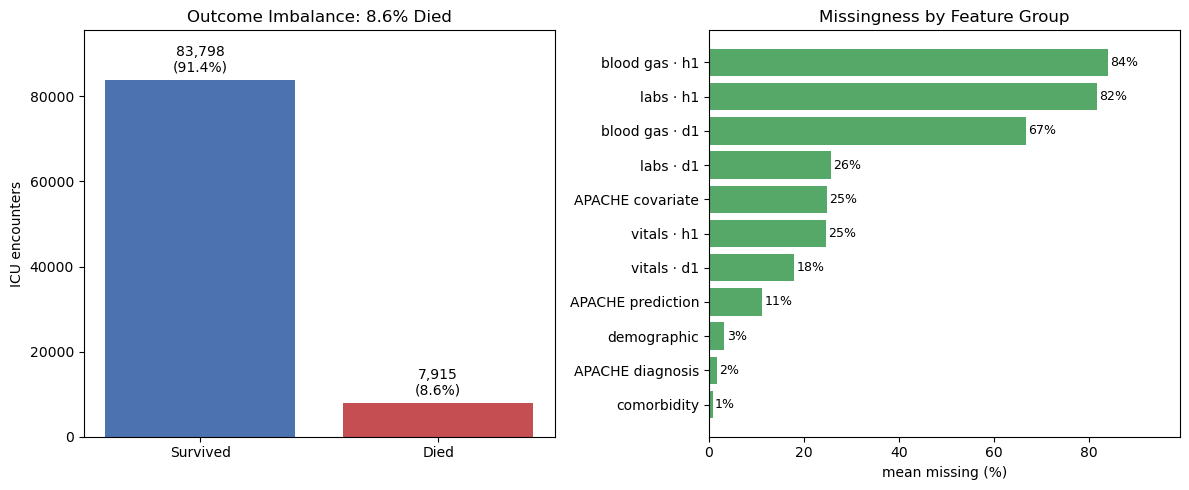

In [11]:
def feature_group(c):
    if c in ["encounter_id","patient_id","hospital_id","icu_id"]: return "identifier"
    if c == TARGET: return "target"
    if c.endswith("_prob"): return "APACHE prediction"
    if "bodysystem" in c or "diagnosis" in c: return "APACHE diagnosis"
    if "apache" in c: return "APACHE covariate"
    if c in ["aids","cirrhosis","diabetes_mellitus","hepatic_failure","immunosuppression",
             "leukemia","lymphoma","solid_tumor_with_metastasis"]: return "comorbidity"
    win = c[:2] if c[:3] in ("d1_", "h1_") else None
    if win:
        if "arterial" in c or "pao2fio2" in c: return f"blood gas · {win}"
        if any(k in c for k in ["heartrate","sysbp","diasbp","mbp","resprate","spo2","temp"]):
            return f"vitals · {win}"
        return f"labs · {win}"
    return "demographic"

grp = pd.Series({c: feature_group(c) for c in df.columns})
gm = (df.isna().mean() * 100).groupby(grp).mean().drop(["identifier","target"], errors="ignore").sort_values()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
counts = df[TARGET].value_counts().sort_index()
ax[0].bar(["Survived","Died"], counts.values, color=["#4C72B0","#C44E52"])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + counts.max() * 0.015, f"{v:,}\n({v/len(df):.1%})", ha="center", va="bottom", fontsize=10)
ax[0].set_ylabel("ICU encounters"); ax[0].set_ylim(0, counts.max()*1.14)
ax[0].set_title(f"Outcome Imbalance: {prev:.1%} Died")

ax[1].barh(gm.index, gm.values, color="#55A868")
for i, v in enumerate(gm.values):
    ax[1].text(v + 0.5, i, f"{v:.0f}%", va="center", fontsize=9)
ax[1].set_xlabel("mean missing (%)"); ax[1].set_xlim(0, max(gm.values)*1.18)
ax[1].set_title("Missingness by Feature Group")
plt.tight_layout()
save_fig(fig, "outcome_imbalance_missingness")
plt.show()

           feature  pct_measured  mort_if_measured  mort_if_missing
    d1_lactate_max         0.254             0.172            0.057
    h1_lactate_max         0.080             0.180            0.078
    d1_albumin_max         0.464             0.111            0.065
  d1_bilirubin_max         0.415             0.111            0.068
d1_arterial_ph_max         0.344             0.162            0.046
        d1_bun_max         0.885             0.087            0.080


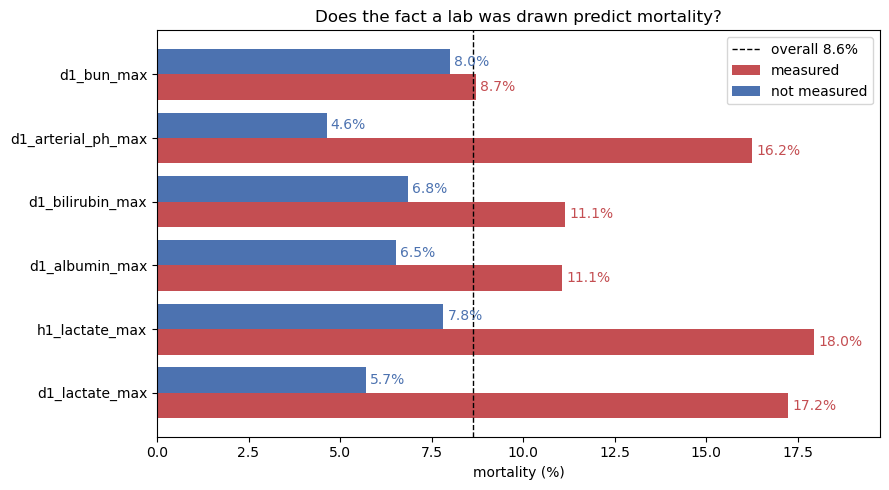

In [12]:
# ON MISSINGNESS - missingness plays a role, doctors draw labs when they worry 
probe = ["d1_lactate_max","h1_lactate_max","d1_albumin_max",
         "d1_bilirubin_max","d1_arterial_ph_max","d1_bun_max"]
probe = [f for f in probe if f in df.columns]
ms = pd.DataFrame([{"feature": f, "pct_measured": df[f].notna().mean(),
                    "mort_if_measured": df.loc[df[f].notna(), TARGET].mean(),
                    "mort_if_missing":  df.loc[df[f].isna(), TARGET].mean()} for f in probe])
print(ms.round(3).to_string(index=False))

yp = np.arange(len(ms))
fig, ax = plt.subplots(figsize=(9, 5))
b_measured = ax.barh(yp-0.2, ms["mort_if_measured"]*100, height=0.4, color="#C44E52", label="measured")
b_missing = ax.barh(yp+0.2, ms["mort_if_missing"]*100,  height=0.4, color="#4C72B0", label="not measured")
ax.bar_label(b_measured, padding=3, fmt="%.1f%%", color="#C44E52")
ax.bar_label(b_missing, padding=3, fmt="%.1f%%", color="#4C72B0")
ax.axvline(prev*100, color="k", ls="--", lw=1, label=f"overall {prev:.1%}")
ax.set_yticks(yp); ax.set_yticklabels(ms["feature"])
ax.set_xlabel("mortality (%)")
ax.set_title("Does the fact a lab was drawn predict mortality?")
max_val = max(ms["mort_if_measured"].max(), ms["mort_if_missing"].max()) * 100
ax.set_xlim(0, max_val * 1.1)
ax.legend()
plt.tight_layout()
plt.show()

Looking at the worst-direction values for patient vitals and labs by survival outcome

saved vitals_labs_boxplot


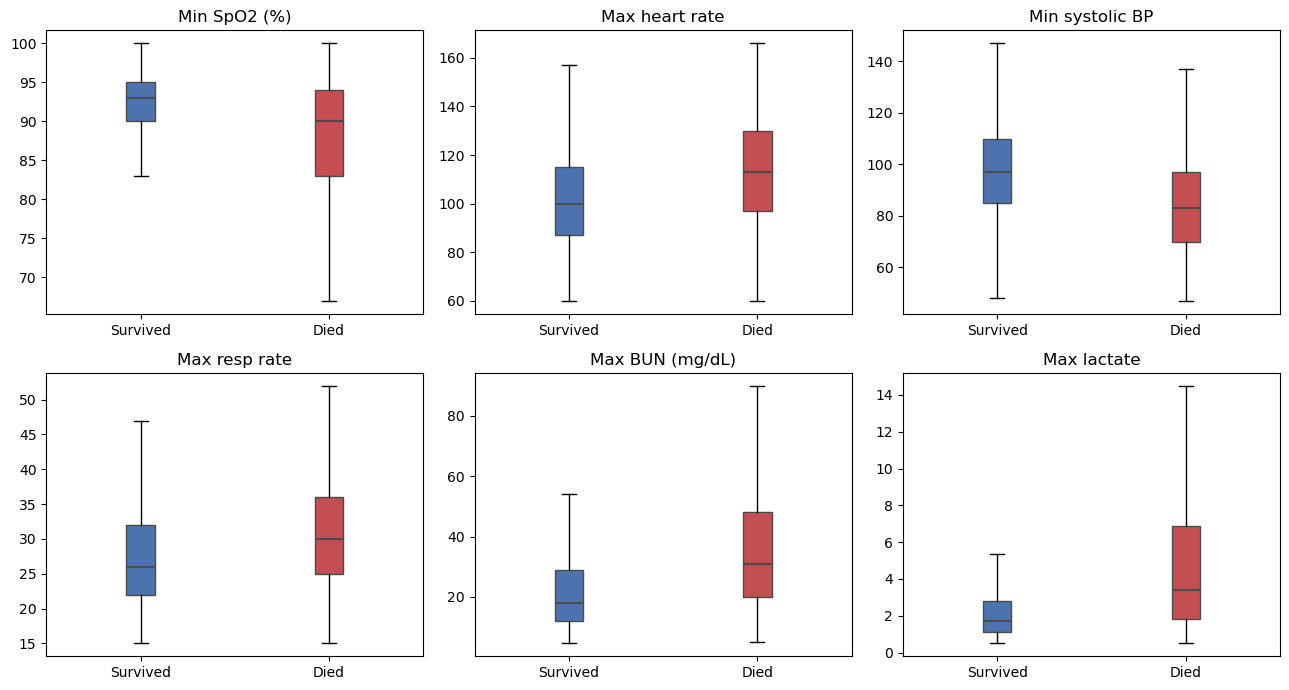

In [13]:
feats = [("d1_spo2_min","Min SpO2 (%)"), ("d1_heartrate_max","Max heart rate"),
         ("d1_sysbp_min","Min systolic BP"), ("d1_resprate_max","Max resp rate"),
         ("d1_bun_max","Max BUN (mg/dL)"), ("d1_lactate_max","Max lactate")]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

colors = ["#4C72B0", "#C44E52"]
for ax_, (f, lab) in zip(axes.ravel(), feats):
    sub = df[[f, TARGET]].dropna()
    lo, hi = sub[f].quantile([0.01, 0.99])
    sub = sub[(sub[f] >= lo) & (sub[f] <= hi)]
    bp = ax_.boxplot([sub.loc[sub[TARGET]==0, f], sub.loc[sub[TARGET]==1, f]], 
                    showfliers=False, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('#4C4C4C')
    for median in bp['medians']:
        median.set_color('#4C4C4C')
        median.set_linewidth(1.5)
    ax_.set_xticks([1, 2]); ax_.set_xticklabels(["Survived", "Died"])
    ax_.set_title(lab)
plt.tight_layout()
save_fig(fig, "vitals_labs_boxplot")
plt.show()

Looking at mortality rates by admit siurce and ICU type 

saved mortality_by_ICU_cat


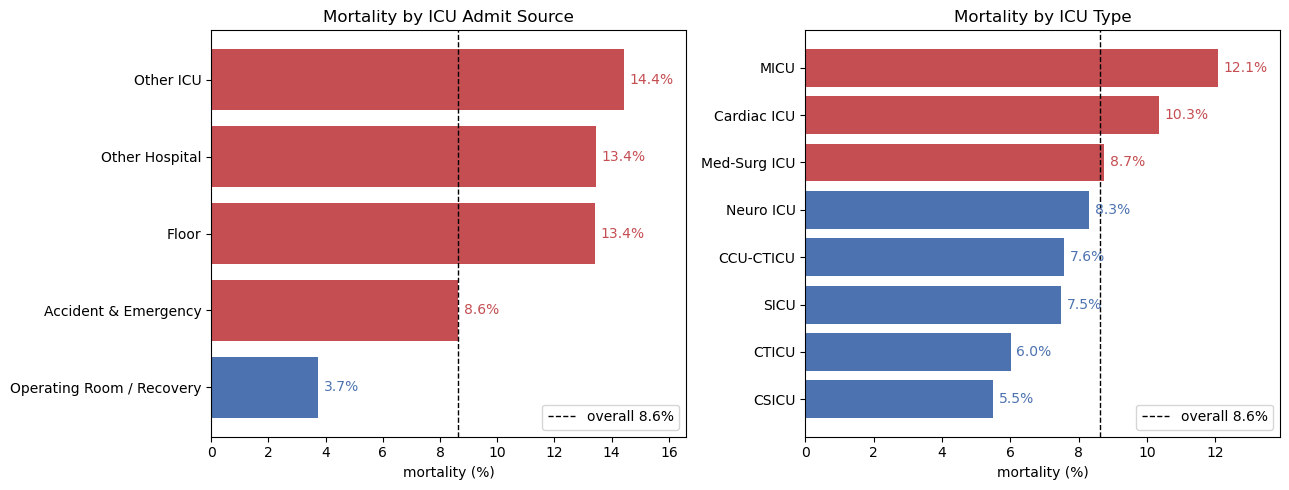

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, col, title in [(ax[0], "icu_admit_source", "Mortality by ICU Admit Source"),
                      (ax[1], "icu_type", "Mortality by ICU Type")]:
    g = df.groupby(col)[TARGET].agg(["mean", "size"])
    g = g[g["size"] >= 100].sort_values("mean")
    bar_values = g["mean"] * 100
    colors = ["#C44E52" if val > 8.6 else "#4C72B0" for val in bar_values]
    
    b = a.barh(g.index.astype(str), bar_values, color=colors)
    labels = a.bar_label(b, padding=4, fmt="%.1f%%")
    
    for text_obj, bar_color in zip(labels, colors):
        text_obj.set_color(bar_color)
    a.axvline(prev*100, color="k", ls="--", lw=1, label=f"overall {prev:.1%}")
    a.margins(x=0.15) 
    a.set_xlabel("mortality (%)")
    a.set_title(title)
    a.legend()

plt.tight_layout()
save_fig(fig, "mortality_by_ICU_cat")
plt.show()

Looking at univariate predictive strength of features

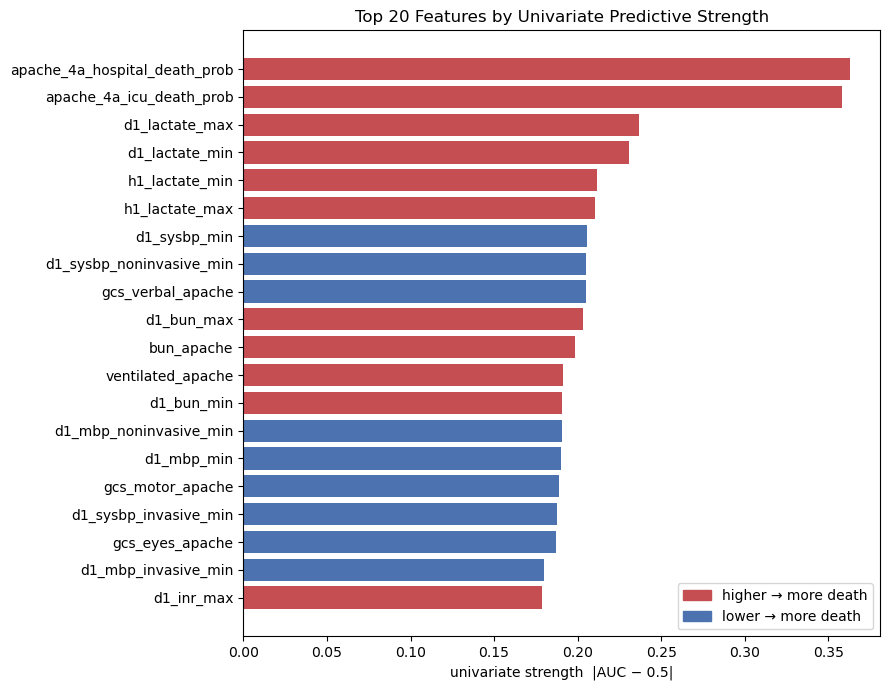

apache_4a_hospital_death_prob    0.863
apache_4a_icu_death_prob         0.858
d1_lactate_max                   0.737
d1_lactate_min                   0.731
h1_lactate_min                   0.712
h1_lactate_max                   0.711
d1_bun_max                       0.703
bun_apache                       0.699
ventilated_apache                0.691
d1_bun_min                       0.691


In [15]:
num = df.select_dtypes("number").drop(columns=["encounter_id", "patient_id", TARGET],
                                       errors="ignore")
aucs = {}
for c in num.columns:
    ok = num[c].notna()
    if ok.sum() < 500 or y[ok].nunique() < 2:
        continue
    aucs[c] = roc_auc_score(y[ok], num[c][ok])

au = pd.Series(aucs)
top = (au - 0.5).abs().sort_values(ascending=False).head(20)
order = top.index[::-1]
colors = ["#C44E52" if au[c] >= 0.5 else "#4C72B0" for c in order]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(order, top.loc[order].values, color=colors)
ax.set_xlabel("univariate strength  |AUC − 0.5|")
ax.set_title("Top 20 Features by Univariate Predictive Strength")
ax.legend(handles=[Patch(color="#C44E52", label="higher → more death"),
                   Patch(color="#4C72B0", label="lower → more death")])
plt.tight_layout()
plt.show()
print(au.sort_values(ascending=False).head(10).round(3).to_string())

Examining the relation of age and comorbidities on mortality

saved age_comorbidity


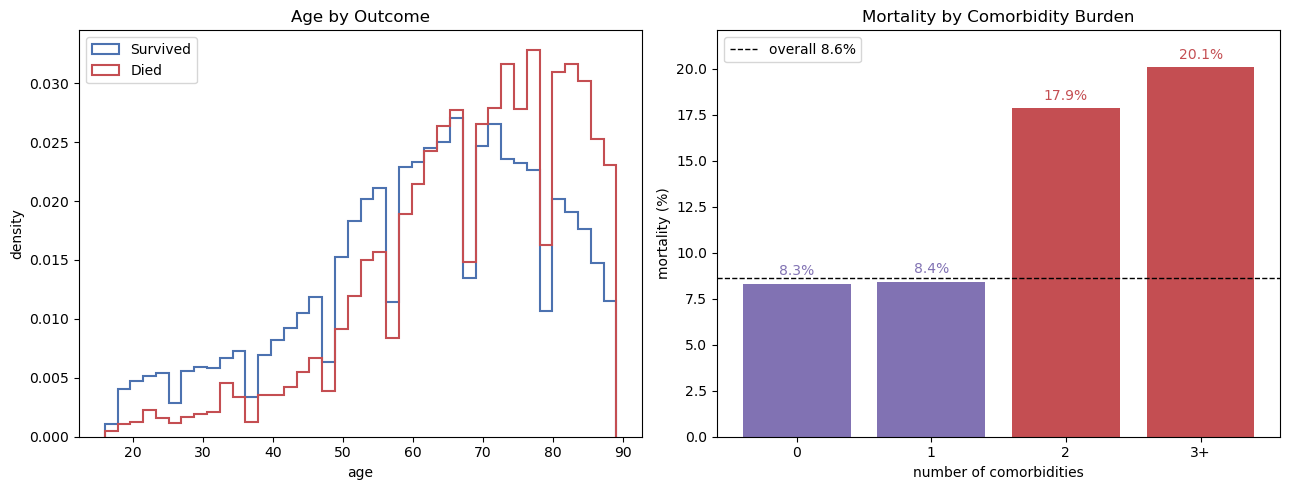

In [16]:
como = ["aids","cirrhosis","diabetes_mellitus","hepatic_failure",
        "immunosuppression","leukemia","lymphoma","solid_tumor_with_metastasis"]
como = [c for c in como if c in df.columns]
ncom = df[como].sum(axis=1, min_count=1).fillna(0).clip(upper=3)
g = pd.DataFrame({"n": ncom, "y": df[TARGET]}).groupby("n")["y"].agg(["mean", "size"])

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for val, lab, col in [(0, "Survived", "#4C72B0"), (1, "Died", "#C44E52")]:
    ax[0].hist(df.loc[df[TARGET]==val, "age"].dropna(), bins=40, density=True,
               histtype="step", label=lab, color=col, lw=1.5)
ax[0].set_xlabel("age")
ax[0].set_ylabel("density")
ax[0].set_title("Age by Outcome")
ax[0].legend()

bar_values = g["mean"] * 100
colors = ["#C44E52" if val > 8.6 else "#8172B3" for val in bar_values]
b_comorb = ax[1].bar([f"{int(i)}{'+' if i>=3 else ''}" for i in g.index], bar_values, color=colors)
labels = ax[1].bar_label(b_comorb, padding=4, fmt="%.1f%%")
for text_obj, bar_color in zip(labels, colors):
    text_obj.set_color(bar_color)
ax[1].margins(y=0.1)
ax[1].axhline(prev*100, color="k", ls="--", lw=1, label=f"overall {prev:.1%}")
ax[1].set_xlabel("number of comorbidities")
ax[1].set_ylabel("mortality (%)")
ax[1].set_title("Mortality by Comorbidity Burden")
ax[1].legend(loc="upper left")

plt.tight_layout()
save_fig(fig, "age_comorbidity")
plt.show()

## Model Building

Perform a 60/20/20 train/calibration/test split

In [17]:
idx = np.arange(len(df))
temp, te  = train_test_split(idx, test_size=0.20, stratify=df[TARGET], random_state=RANDOM_STATE)
tr, cal = train_test_split(temp, test_size=0.25, stratify=df[TARGET].iloc[tr], random_state=RANDOM_STATE)

# verify sizes and that the death rate is preserved everywhere
for name, ix in [("fit (train)", tr), ("calibration", cal), ("test", te)]:
    print(f"{name:14s} n={len(ix):>6,}   mortality={df[TARGET].iloc[ix].mean():.1%}")

fit (train)    n=55,027   mortality=8.6%
calibration    n=18,343   mortality=8.6%
test           n=18,343   mortality=8.6%


Training the baseline and proposed models

In [18]:
def make_logreg():
    return LogisticRegression(max_iter=4000, class_weight="balanced", C=1.0) # baseline

def make_catboost():
    return CatBoostClassifier(iterations=600, learning_rate=0.03, depth=6,
                              auto_class_weights="Balanced",
                              random_seed=RANDOM_STATE, verbose=0) # proposed

X, y, cat, num = build_feature_frame(df, "A_apache_inclusive")
lr_pipe = Pipeline([("prep", make_preprocessor(cat, num)), ("clf", make_logreg())])
cb_pipe = Pipeline([("prep", make_preprocessor(cat, num)), ("clf", make_catboost())])

t0 = time.time()
lr_pipe.fit(X.iloc[tr], y.iloc[tr]); print(f"LogReg trained in {time.time()-t0:.1f}s")
t0 = time.time()
cb_pipe.fit(X.iloc[tr], y.iloc[tr]); print(f"CatBoost trained in {time.time()-t0:.1f}s")

# check: uncalibrated ranking quality on the test set
for name, pipe in [("LogReg", lr_pipe), ("CatBoost", cb_pipe)]:
    p = pipe.predict_proba(X.iloc[te])[:, 1]
    print(f"{name:9s} uncalibrated test ROC-AUC = {roc_auc_score(y.iloc[te], p):.4f}")

LogReg trained in 16.5s
CatBoost trained in 24.0s
LogReg    uncalibrated test ROC-AUC = 0.8894
CatBoost  uncalibrated test ROC-AUC = 0.9013


Calibration step

In [19]:
def calibrate_prefit(model, Xc, yc, method="sigmoid"):
    return CalibratedClassifierCV(FrozenEstimator(model), method=method).fit(Xc, yc)

lr_sig = calibrate_prefit(lr_pipe, X.iloc[cal], y.iloc[cal], "sigmoid") # baseline
cb_sig = calibrate_prefit(cb_pipe, X.iloc[cal], y.iloc[cal], "sigmoid") # proposed

# before/after on the test set
for name, raw, cal_m in [("LogReg", lr_pipe, lr_sig), ("CatBoost", cb_pipe, cb_sig)]:
    p_raw = raw.predict_proba(X.iloc[te])[:, 1]
    p_cal = cal_m.predict_proba(X.iloc[te])[:, 1]
    print(f"{name:9s}  AUC {roc_auc_score(y.iloc[te], p_raw):.4f} -> {roc_auc_score(y.iloc[te], p_cal):.4f}"
          f"   Brier {brier_score_loss(y.iloc[te], p_raw):.4f} -> {brier_score_loss(y.iloc[te], p_cal):.4f}")

LogReg     AUC 0.8894 -> 0.8894   Brier 0.1279 -> 0.0556
CatBoost   AUC 0.9013 -> 0.9013   Brier 0.1140 -> 0.0546


Full evaluation on the test set

In [20]:
def ece(y_true, p, n_bins=10):
    idx = np.clip(np.digitize(p, np.linspace(0, 1, n_bins + 1)) - 1, 0, n_bins - 1)
    e = 0.0
    for b in range(n_bins):
        m = idx == b
        if m.sum():
            e += m.sum()/len(p) * abs(y_true[m].mean() - p[m].mean())
    return e

def metrics(y_true, p):
    return {"ROC_AUC": roc_auc_score(y_true, p), "PR_AUC": average_precision_score(y_true, p),
            "Brier": brier_score_loss(y_true, p), "LogLoss": log_loss(y_true, p),
            "ECE": ece(np.asarray(y_true), np.asarray(p))}

yte = np.asarray(y.iloc[te])
rows = []
for name, model in [("LogReg + sigmoid (baseline)", lr_sig),
                    ("CatBoost + sigmoid (proposed)", cb_sig)]:
    p = model.predict_proba(X.iloc[te])[:, 1]
    rows.append({"Model": name, **{k: round(v, 4) for k, v in metrics(yte, p).items()}})
print(pd.DataFrame(rows).to_string(index=False))

                        Model  ROC_AUC  PR_AUC  Brier  LogLoss    ECE
  LogReg + sigmoid (baseline)   0.8894  0.5387 0.0556   0.1942 0.0076
CatBoost + sigmoid (proposed)   0.9013  0.5750 0.0546   0.1902 0.0163


saved model_eval


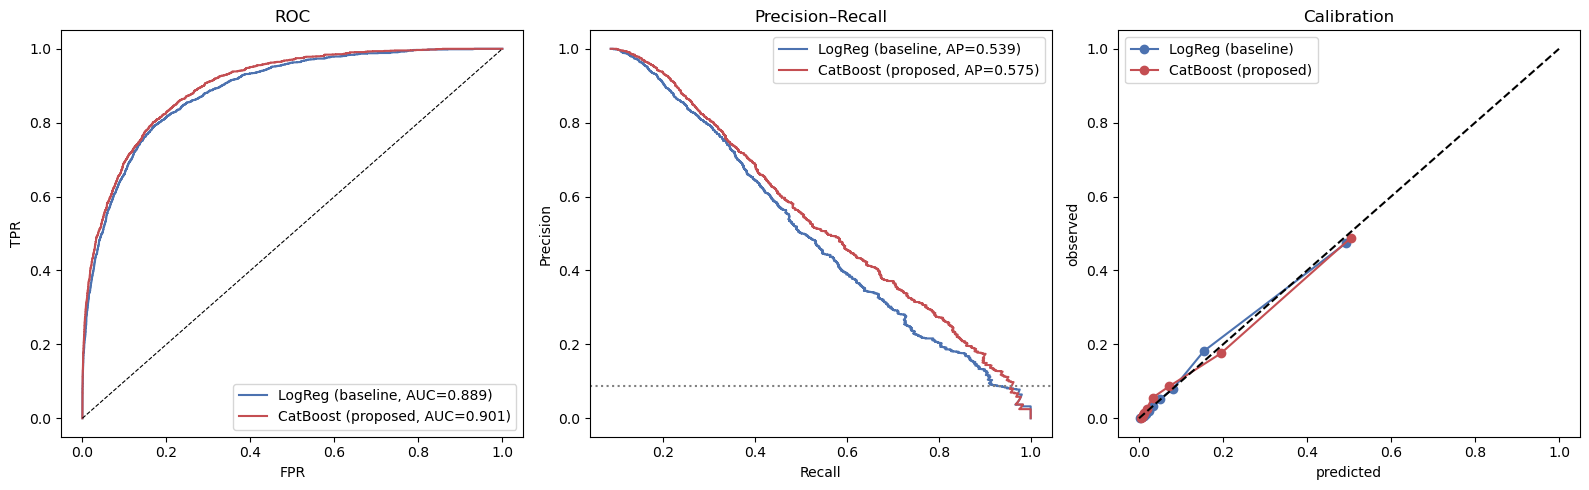

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
for name, model, c, label_type in [("LogReg", lr_sig, "#4C72B0", "baseline"), 
                                   ("CatBoost", cb_sig, "#C44E52", "proposed")]:
    p = model.predict_proba(X.iloc[te])[:, 1]

    # Plot 1: ROC Curve
    fpr, tpr, _ = roc_curve(yte, p)
    ax[0].plot(fpr, tpr, color=c, label=f"{name} ({label_type}, AUC={roc_auc_score(yte, p):.3f})")
    
    # Plot 2: Precision-Recall Curve
    rc_, pr_, _ = precision_recall_curve(yte, p)
    ax[1].plot(rc_, pr_, color=c, label=f"{name} ({label_type}, AP={average_precision_score(yte, p):.3f})")
    
    # Plot 3: Calibration Curve
    fp, mp = calibration_curve(yte, p, n_bins=10, strategy="quantile")
    ax[2].plot(mp, fp, "o-", color=c, label=f"{name} ({label_type})")

ax[0].plot([0,1],[0,1],"k--",lw=.8); ax[0].set_title("ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
ax[1].axhline(yte.mean(), color="grey", ls=":"); ax[1].set_title("Precision–Recall"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
ax[2].plot([0,1],[0,1],"k--"); ax[2].set_title("Calibration"); ax[2].set_xlabel("predicted"); ax[2].set_ylabel("observed"); ax[2].legend()
plt.tight_layout()
save_fig(fig, "model_eval")
plt.show()

## Analyses

Threshold analysis

In [22]:
def threshold_table(y_true, p, ts):
    out = []
    for t in ts:
        pred = (p >= t).astype(int)
        tp = ((pred==1)&(y_true==1)).sum(); fp = ((pred==1)&(y_true==0)).sum()
        fn = ((pred==0)&(y_true==1)).sum(); tn = ((pred==0)&(y_true==0)).sum()
        out.append({"threshold": t,
                    "sensitivity": round(tp/(tp+fn), 3) if tp+fn else 0,
                    "specificity": round(tn/(tn+fp), 3) if tn+fp else 0,
                    "PPV": round(tp/(tp+fp), 3) if tp+fp else 0,
                    "flagged_%": round(pred.mean()*100, 1)})
    return pd.DataFrame(out)

p_cb = cb_sig.predict_proba(X.iloc[te])[:, 1]
print(threshold_table(yte, p_cb, [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]).to_string(index=False))

 threshold  sensitivity  specificity   PPV  flagged_%
      0.05        0.861        0.767 0.259       28.7
      0.10        0.782        0.845 0.323       20.9
      0.15        0.723        0.881 0.365       17.1
      0.20        0.673        0.907 0.405       14.3
      0.30        0.581        0.941 0.481       10.4
      0.50        0.396        0.982 0.671        5.1


saved threshold_tradeoff


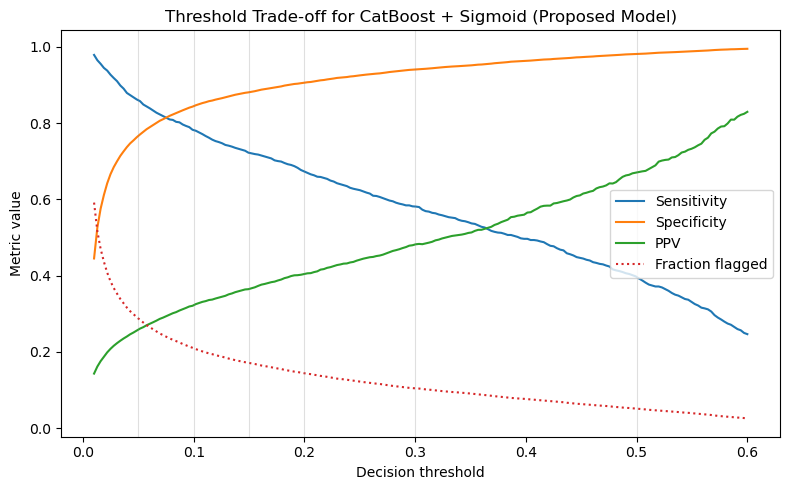

In [23]:
g = np.linspace(0.01, 0.60, 200)
rows = []
for t in g:
    pred = (p_cb >= t).astype(int)
    tp=((pred==1)&(yte==1)).sum(); fp=((pred==1)&(yte==0)).sum()
    fn=((pred==0)&(yte==1)).sum(); tn=((pred==0)&(yte==0)).sum()
    rows.append({"sensitivity": tp/(tp+fn) if tp+fn else 0,
                 "specificity": tn/(tn+fp) if tn+fp else 0,
                 "ppv":         tp/(tp+fp) if tp+fp else 0,
                 "flagged":     pred.mean()})
mgdf = pd.DataFrame(rows)

SWEEP = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(g, mgdf["sensitivity"], label="Sensitivity")
ax.plot(g, mgdf["specificity"], label="Specificity")
ax.plot(g, mgdf["ppv"],         label="PPV")
ax.plot(g, mgdf["flagged"],     label="Fraction flagged", ls=":")
for t in SWEEP:
    ax.axvline(t, color="grey", alpha=0.25, lw=0.8)
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Metric value")
ax.set_title("Threshold Trade-off for CatBoost + Sigmoid (Proposed Model)")
ax.legend()
plt.tight_layout()
save_fig(fig, "threshold_tradeoff")
plt.show()

APACHE sensitivity analysis

In [24]:
abl = []
for setting in ["A_apache_inclusive", "B_apache_prob_excluded",
                "C_apache_derived_excluded", "D_apache_only"]:
    Xs, ys, cs, ns = build_feature_frame(df, setting)
    pipe = Pipeline([("prep", make_preprocessor(cs, ns)), ("clf", make_catboost())]).fit(Xs.iloc[tr], ys.iloc[tr])
    p = pipe.predict_proba(Xs.iloc[te])[:, 1]
    abl.append({"setting": setting, "n_features": Xs.shape[1],
                "ROC_AUC": round(roc_auc_score(yte, p), 4),
                "PR_AUC":  round(average_precision_score(yte, p), 4)})
print(pd.DataFrame(abl).to_string(index=False))

                  setting  n_features  ROC_AUC  PR_AUC
       A_apache_inclusive         177   0.9013  0.5750
   B_apache_prob_excluded         175   0.9033  0.5723
C_apache_derived_excluded         146   0.8875  0.5306
            D_apache_only           2   0.8448  0.4369


Test APACHE reliance

saved shap


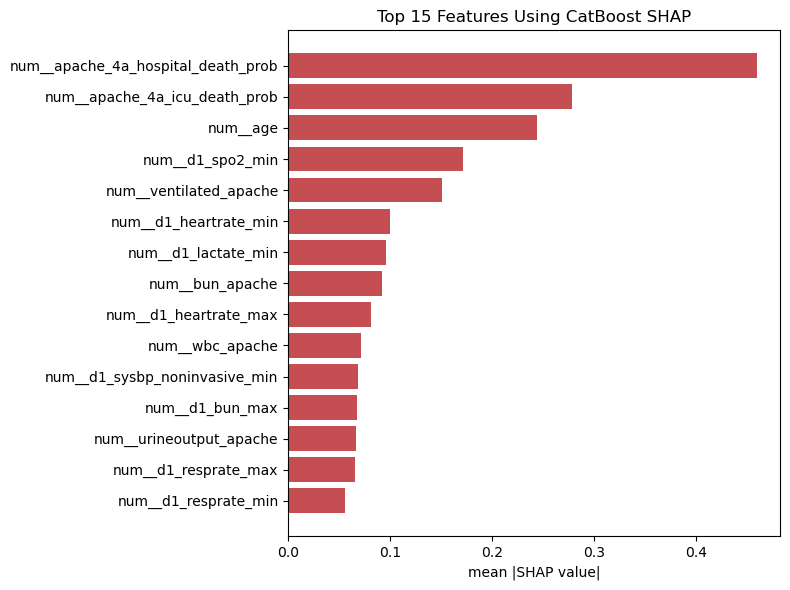

num__apache_4a_hospital_death_prob    0.4593
num__apache_4a_icu_death_prob         0.2779
num__age                              0.2437
num__d1_spo2_min                      0.1715
num__ventilated_apache                0.1504
num__d1_heartrate_min                 0.0999
num__d1_lactate_min                   0.0954
num__bun_apache                       0.0923
num__d1_heartrate_max                 0.0814
num__wbc_apache                       0.0714
num__d1_sysbp_noninvasive_min         0.0680
num__d1_bun_max                       0.0673
num__urineoutput_apache               0.0660
num__d1_resprate_max                  0.0653
num__d1_resprate_min                  0.0556


In [25]:
prep, clf = cb_pipe.named_steps["prep"], cb_pipe.named_steps["clf"]
names = list(prep.get_feature_names_out())

n = min(2000, len(te))
samp = np.random.RandomState(RANDOM_STATE).choice(len(te), n, replace=False)
Xenc = prep.transform(X.iloc[te].iloc[samp])

shap_vals = clf.get_feature_importance(Pool(Xenc), type="ShapValues")[:, :-1]  # last col is the base value
imp = pd.Series(np.abs(shap_vals).mean(0), index=names).sort_values(ascending=False)

top = imp.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index, top.values, color="#C44E52")
ax.set_xlabel("mean |SHAP value|"); ax.set_title("Top 15 Features Using CatBoost SHAP")
plt.tight_layout()
save_fig(fig, "shap")
plt.show()
print(imp.head(15).round(4).to_string())

## Demo on simplified model

In [26]:
NUMERIC = ["age","bmi","d1_heartrate_max","d1_heartrate_min","d1_sysbp_min","d1_spo2_min",
           "d1_temp_max","d1_resprate_max","d1_glucose_max",
           "ventilated_apache","intubated_apache","elective_surgery"]
CATEG = ["gender","icu_type","icu_admit_source"]
BINARY = {"ventilated_apache","intubated_apache","elective_surgery"}
GROUPS = [
    {"id":"background","label":"Patient background"},
    {"id":"vitals","label":"Vital signs & labs"},
    {"id":"status","label":"Treatment & status"},
    {"id":"admission","label":"Admission"},
]
FIELDS = [
    {"key":"age","label":"Age (years)","type":"number","group":"background"},
    {"key":"bmi","label":"BMI","type":"number","group":"background"},
    {"key":"gender","label":"Sex","type":"category","group":"background"},
    {"key":"d1_heartrate_max","label":"Highest heart rate (bpm)","type":"number","group":"vitals"},
    {"key":"d1_heartrate_min","label":"Lowest heart rate (bpm)","type":"number","group":"vitals"},
    {"key":"d1_sysbp_min","label":"Lowest systolic BP (mmHg)","type":"number","group":"vitals"},
    {"key":"d1_spo2_min","label":"Lowest oxygen, SpO2 (%)","type":"number","group":"vitals"},
    {"key":"d1_temp_max","label":"Highest temperature (ºC)","type":"number","group":"vitals"},
    {"key":"d1_resprate_max","label":"Highest breathing rate (/min)","type":"number","group":"vitals"},
    {"key":"d1_glucose_max","label":"Highest blood sugar (mg/dL)","type":"number","group":"vitals"},
    {"key":"ventilated_apache","label":"On a ventilator","type":"binary","group":"status"},
    {"key":"intubated_apache","label":"Has a breathing tube","type":"binary","group":"status"},
    {"key":"elective_surgery","label":"Planned (elective) surgery","type":"binary","group":"status"},
    {"key":"icu_type","label":"ICU type","type":"category","group":"admission"},
    {"key":"icu_admit_source","label":"Came to ICU from","type":"category","group":"admission"},
]

def _stats(part):
    st = {"numeric":{}, "categorical":{}}
    for f in NUMERIC:
        x = pd.to_numeric(part[f], errors="coerce"); med=float(x.median()); xi=x.fillna(med)
        st["numeric"][f] = {"median":med,"mean":float(xi.mean()),"std":float(xi.std()) or 1.0}
    for c in CATEG:
        s = df[c].astype("string")
        st["categorical"][c] = {"categories":sorted(s.dropna().unique().tolist()),"mode":str(s.mode().iloc[0])}
    return st

def _design(part, st):
    cols, names = [], []
    for f in NUMERIC:
        x = pd.to_numeric(part[f], errors="coerce").fillna(st["numeric"][f]["median"]).to_numpy(float)
        cols.append((x - st["numeric"][f]["mean"]) / st["numeric"][f]["std"]); names.append(f)
    for c in CATEG:
        s = part[c].astype("string").fillna(st["categorical"][c]["mode"])
        for cat in st["categorical"][c]["categories"]:
            cols.append((s == cat).to_numpy(float)); names.append(f"{c}={cat}")
    return np.column_stack(cols), names

st = _stats(df.iloc[tr])
Xfit, names = _design(df.iloc[tr], st); Xcal, _ = _design(df.iloc[cal], st); Xte_d, _ = _design(df.iloc[te], st)
ytr, ycal, yte_d = y.iloc[tr].to_numpy(), y.iloc[cal].to_numpy(), y.iloc[te].to_numpy()
lr = LogisticRegression(max_iter=4000, class_weight="balanced", C=1.0).fit(Xfit, ytr)
w, b = lr.coef_[0], float(lr.intercept_[0])
platt = LogisticRegression(max_iter=4000, C=1e6).fit((Xcal @ w + b).reshape(-1,1), ycal)

p_te = platt.predict_proba((Xte_d @ w + b).reshape(-1,1))[:,1]
performance = {"roc_auc":round(float(roc_auc_score(yte_d,p_te)),3),
               "pr_auc":round(float(average_precision_score(yte_d,p_te)),3),
               "brier":round(float(brier_score_loss(yte_d,p_te)),3), "n_test":int(len(te))}

defaults = {f: round(st["numeric"][f]["median"], 2) for f in NUMERIC}
for f in BINARY: defaults[f] = 0
for c in CATEG: defaults[c] = st["categorical"][c]["mode"]
PRESETS = {
  "Lower risk": {"age":45,"bmi":24,"d1_heartrate_max":92,"d1_heartrate_min":64,"d1_sysbp_min":116,
                 "d1_spo2_min":97,"d1_temp_max":37.0,"d1_resprate_max":16,"d1_glucose_max":110,
                 "ventilated_apache":0,"intubated_apache":0,"elective_surgery":1},
  "Typical": {},
  "Higher risk": {"age":78,"bmi":31,"d1_heartrate_max":132,"d1_heartrate_min":48,"d1_sysbp_min":76,
                  "d1_spo2_min":84,"d1_temp_max":38.8,"d1_resprate_max":30,"d1_glucose_max":245,
                  "ventilated_apache":1,"intubated_apache":1,"elective_surgery":0},
}
payload = {"numeric_features":NUMERIC,"categorical_features":CATEG,
           "coef":{n:float(wi) for n,wi in zip(names,w)},"intercept":b,
           "platt":{"a":float(platt.coef_[0,0]),"b":float(platt.intercept_[0])},
           "stats":st,"groups":GROUPS,"fields":FIELDS,"defaults":defaults,
           "presets":PRESETS,"performance":performance}

HTML = """<!DOCTYPE html><html lang="en"><head><meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Demo: ICU Mortality Risk Prediction</title><style>
:root{--bg:#f7f7f5;--card:#fff;--ink:#1f2328;--muted:#6b7280;--line:#e5e7eb;--accent:#4C72B0;}
*{box-sizing:border-box;}body{margin:0;font-family:-apple-system,Segoe UI,Roboto,Arial,sans-serif;background:var(--bg);color:var(--ink);line-height:1.5;}
.wrap{max-width:860px;margin:0 auto;padding:24px 16px 60px;}h1{font-size:22px;margin:0 0 4px;}
.sub{color:var(--muted);margin:0 0 16px;}
.disc{background:#fff7ed;border:1px solid #fed7aa;color:#9a3412;padding:10px 14px;border-radius:8px;font-size:14px;margin-bottom:18px;}
.banner{position:sticky;top:0;z-index:5;background:var(--card);border:1px solid var(--line);border-radius:12px;padding:16px 20px;margin-bottom:18px;display:flex;align-items:center;gap:28px;flex-wrap:wrap;}
.banner .rl{font-size:13px;color:var(--muted);}.banner .pct{font-size:44px;font-weight:600;line-height:1;margin-top:2px;}
.b-right{flex:1;min-width:200px;}.bar{height:12px;border-radius:999px;background:#eee;overflow:hidden;margin-bottom:6px;}.bar>div{height:100%;transition:width .25s,background .25s;}
.card{background:var(--card);border:1px solid var(--line);border-radius:12px;padding:18px;margin-bottom:18px;}
.preset-row{display:flex;align-items:center;gap:10px;flex-wrap:wrap;margin-bottom:6px;}.preset-label{font-size:13px;color:var(--muted);}
.presets{display:flex;gap:8px;flex-wrap:wrap;}.presets button{border:1px solid var(--line);background:#fff;border-radius:999px;padding:6px 14px;font-size:14px;cursor:pointer;}
.presets button:hover{border-color:var(--accent);color:var(--accent);}.preset-hint{font-size:12px;color:var(--muted);margin:0 0 16px;}
.section{margin-bottom:18px;}.section:last-child{margin-bottom:0;}.section h3{font-size:13px;font-weight:600;color:var(--accent);margin:0 0 10px;}
.fgrid{display:grid;grid-template-columns:repeat(auto-fit,minmax(210px,1fr));gap:12px 16px;}
.field label{display:block;font-size:13px;color:var(--muted);margin-bottom:4px;}
.field input[type=number],.field select{width:100%;padding:7px 9px;border:1px solid var(--line);border-radius:8px;font-size:14px;background:#fff;}
.field.binary{display:flex;align-items:center;gap:8px;}.field.binary label{margin:0;font-size:14px;color:var(--ink);}
.perf p{margin:6px 0;font-size:14px;}.perf .muted{color:var(--muted);font-size:13px;}
</style></head><body><div class="wrap">
<h1>ICU In-Hospital Mortality — An Educational Demo</h1>
<p class="sub">A simplified, calibrated model. Pick an example patient or adjust the inputs.</p>
<div class="disc"><b>Educational use only, not for clinical use.</b> This is a simplified illustrative model; do not use it for real medical decisions. Privacy protection: all computation runs in your browser, so no data is sent anywhere.</div>
<div class="banner"><div><div class="rl">Estimated in-hospital mortality risk</div><div class="pct" id="pct">-</div></div>
<div class="b-right"><div class="bar"><div id="bf"></div></div><div class="rl" id="rw"></div></div></div>
<div class="card"><div class="preset-row"><span class="preset-label">Try an example patient:</span><div class="presets" id="presets"></div></div>
<p class="preset-hint">These fill the form with a sample patient. Then, adjust any field to see the risk change.</p>
<div id="fields"></div></div>
<div class="card perf"><h3 style="color:var(--accent);font-size:13px;margin:0 0 8px;">About this model</h3>
<p>Performance on a held-out test set: ROC-AUC <b id="m_auc"></b> &middot; PR-AUC <b id="m_pr"></b> &middot; Brier <b id="m_brier"></b> (n = <span id="m_n"></span>).</p>
<p class="muted">This logistic regression model is deliberately simplified and browser-friendly using 15 plain inputs. The full model, gradient-boosted trees on the complete feature set, scores higher, around ROC-AUC 0.90.</p></div>
</div><script>
const MODEL=__MODEL_JSON__;let state=Object.assign({},MODEL.defaults);
function sig(z){return 1/(1+Math.exp(-z));}
function predict(v){let L=MODEL.intercept;
 for(const f of MODEL.numeric_features){const s=MODEL.stats.numeric[f];
  const x=(v[f]===""||v[f]==null)?s.median:Number(v[f]);L+=(MODEL.coef[f]||0)*(x-s.mean)/s.std;}
 for(const c of MODEL.categorical_features){for(const cat of MODEL.stats.categorical[c].categories){
  L+=(MODEL.coef[c+"="+cat]||0)*(v[c]===cat?1:0);}}
 return sig(MODEL.platt.a*L+MODEL.platt.b);}
function render(){const p=predict(state);document.getElementById('pct').textContent=(p*100).toFixed(1)+'%';
 const bf=document.getElementById('bf');bf.style.width=Math.min(100,p*120)+'%';
 bf.style.background=p<0.1?'#4C72B0':(p<0.3?'#DD8452':'#C44E52');
 document.getElementById('rw').textContent=p<0.1?'lower than typical':(p<0.3?'elevated':'high');}
function setVal(k,x){state[k]=x;render();}
function fieldEl(f){const w=document.createElement('div');
 if(f.type==='binary'){w.className='field binary';
  w.innerHTML='<input type="checkbox" id="'+f.key+'"><label for="'+f.key+'">'+f.label+'</label>';
  const cb=w.querySelector('input');cb.checked=!!state[f.key];cb.onchange=()=>setVal(f.key,cb.checked?1:0);}
 else if(f.type==='category'){w.className='field';
  const o=MODEL.stats.categorical[f.key].categories.map(c=>'<option>'+c+'</option>').join('');
  w.innerHTML='<label>'+f.label+'</label><select>'+o+'</select>';
  const s=w.querySelector('select');s.value=state[f.key];s.onchange=()=>setVal(f.key,s.value);}
 else{w.className='field';w.innerHTML='<label>'+f.label+'</label><input type="number" value="'+state[f.key]+'">';
  const i=w.querySelector('input');i.oninput=()=>setVal(f.key,i.value);}
 return w;}
function buildForm(){const fc=document.getElementById('fields');fc.innerHTML='';
 for(const g of MODEL.groups){const sec=document.createElement('div');sec.className='section';
  const h=document.createElement('h3');h.textContent=g.label;sec.appendChild(h);
  const grid=document.createElement('div');grid.className='fgrid';
  for(const f of MODEL.fields.filter(x=>x.group===g.id)) grid.appendChild(fieldEl(f));
  sec.appendChild(grid);fc.appendChild(sec);}}
function buildPresets(){const pc=document.getElementById('presets');
 for(const n of Object.keys(MODEL.presets)){const b=document.createElement('button');b.textContent=n;
  b.onclick=()=>{state=Object.assign({},MODEL.defaults,MODEL.presets[n]);buildForm();render();};pc.appendChild(b);}}
function showPerf(){const p=MODEL.performance;document.getElementById('m_auc').textContent=p.roc_auc;
 document.getElementById('m_pr').textContent=p.pr_auc;document.getElementById('m_brier').textContent=p.brier;
 document.getElementById('m_n').textContent=p.n_test.toLocaleString();}
buildPresets();buildForm();showPerf();render();
</script></body></html>"""

Path("docs").mkdir(exist_ok=True)
Path("docs/index.html").write_text(HTML.replace("__MODEL_JSON__", json.dumps(payload)))
print(f"wrote demo/index.html — demo model test ROC-AUC = {performance['roc_auc']}")

wrote demo/index.html — demo model test ROC-AUC = 0.836
